Dataset --Boston House Dataset from Kaggle

# Importing the Dependencies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


# Data Collection

In [4]:
house_dataset = pd.read_csv("/content/extracted_data/boston.csv")

# Data Preprocessing

#### MEDV are the prices of  houses -- 24 thousand dollars -- Target Variable

In [5]:
#printing the 1st 5 rows of the dataset
house_dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
#checking the dataset
print(house_dataset)

        CRIM    ZN  INDUS  CHAS    NOX  ...    TAX  PTRATIO       B  LSTAT  MEDV
0    0.00632  18.0   2.31     0  0.538  ...  296.0     15.3  396.90   4.98  24.0
1    0.02731   0.0   7.07     0  0.469  ...  242.0     17.8  396.90   9.14  21.6
2    0.02729   0.0   7.07     0  0.469  ...  242.0     17.8  392.83   4.03  34.7
3    0.03237   0.0   2.18     0  0.458  ...  222.0     18.7  394.63   2.94  33.4
4    0.06905   0.0   2.18     0  0.458  ...  222.0     18.7  396.90   5.33  36.2
..       ...   ...    ...   ...    ...  ...    ...      ...     ...    ...   ...
501  0.06263   0.0  11.93     0  0.573  ...  273.0     21.0  391.99   9.67  22.4
502  0.04527   0.0  11.93     0  0.573  ...  273.0     21.0  396.90   9.08  20.6
503  0.06076   0.0  11.93     0  0.573  ...  273.0     21.0  396.90   5.64  23.9
504  0.10959   0.0  11.93     0  0.573  ...  273.0     21.0  393.45   6.48  22.0
505  0.04741   0.0  11.93     0  0.573  ...  273.0     21.0  396.90   7.88  11.9

[506 rows x 14 columns]


In [7]:
# printing the last 5 rows of the dataset
house_dataset.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [9]:
#checking the number of rows and columns in dataset
house_dataset.shape

(506, 14)

In [10]:
# Checking the null values
house_dataset.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [11]:
#finding the information about the dataset
house_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [12]:
#Finding the Statistical Measures
house_dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# Data Analytics

#### data correlation -- understanding the relationship between different columns

1. Positive Correlation
                         one value increase other increase too

2.Negative Correlation
                        one value increase other decrease

In [13]:
# Finding the correlation
correlation = house_dataset.corr()

####.cbar -- color bar -- the separate line of colors

####. square -- Represent the shape

####. fmt = 1f -- means the output value can only be upto one decimal place --1 floating point

####. annot=True --  tells Seaborn to write the data value (the correlation coefficient in this case) into each cell of the heatmap.

####. annot_Kws -- means the font size inside the heatmap cells of the annotations

####.  cmap = Blues means the color of the heatmap cells

<Axes: >

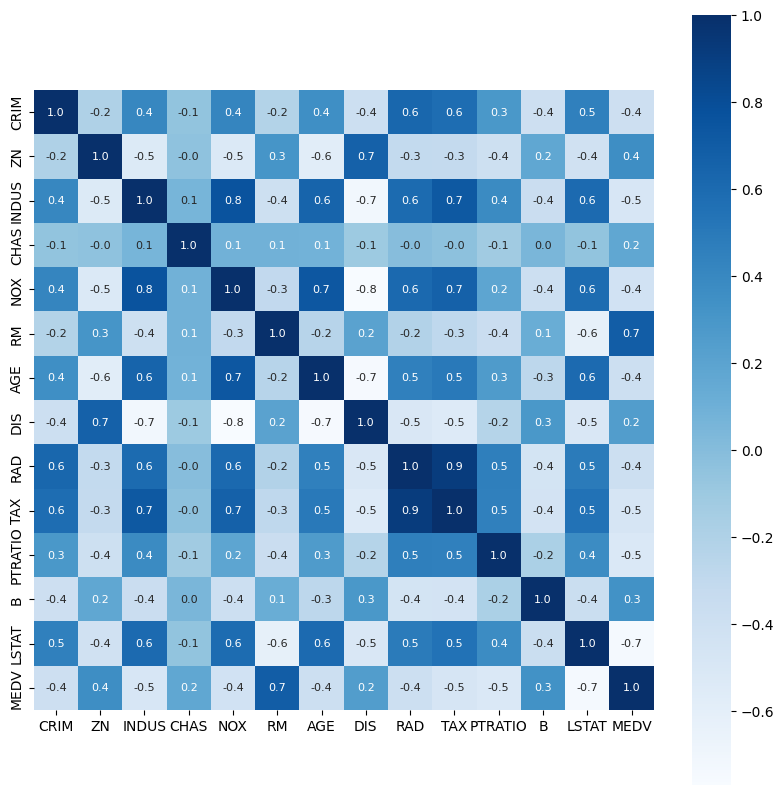

In [15]:
#Constructing the Heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation , cbar = True , square=True , fmt='.1f' , annot=True , annot_kws= {"size" :8} , cmap='Blues' )


# Split the data into Features and Traget

In [16]:
# X--- Features -- independent
X = house_dataset.drop(['MEDV'] , axis=1)
# y --- Target -- dependent
y = house_dataset['MEDV']

In [17]:
#printing the X
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [18]:
#printing the y
y

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


# Splitting the data into Training or Testing data

In [21]:
# dividing the dataset into Training or Testing data
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.3 , random_state= 42)

In [24]:
#  Finding the number of rows or column in the X
X.shape

(506, 13)

In [22]:
# Finding the number of rows or column in the X_train
X_train.shape

(354, 13)

In [23]:
# Finding the number of rows or column in the X_test
X_test.shape

(152, 13)

# Model Creation

In [25]:
xgbr_model = XGBRegressor()

In [26]:
# Fitting the data in the model
xgbr_model.fit(X_train , y_train )

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

# Prediction on Training data

In [27]:
#accuracy for training
training_data_prediction = xgbr_model.predict(X_train)

In [28]:
# printing the accuracy
print(training_data_prediction)

[28.696657  21.196432  19.300293  23.09678   19.101131  24.99391
 33.40596    4.9979362 29.585997  18.700586  21.699917  23.086199
 22.79635   21.000452  48.78995   14.632211  16.609575  27.088827
 20.08926   19.805834  20.994942  41.293972  23.191757  20.376076
 18.537794  29.394043  36.39943   24.404903  11.808582  13.802007
 12.277543  17.800543  33.095093  26.695942  13.393357  14.397082
 50.006687  22.003748  19.910648  23.788357  17.505146  12.669764
  5.6054873 31.101807  26.202066  19.376616  16.697231  13.802823
 22.905523  15.301785  27.500906  36.098614  22.891525  24.49007
 24.998152  49.999165  34.890015  31.699364  24.106739  22.115704
 14.10371   42.79694   19.313747  32.202724  26.388634  21.800003
 21.691446   8.302905  46.69915   43.109062  31.50057   10.5006485
 16.698845  20.004932  33.31154   17.799757  49.999165  20.500994
 23.194735  13.08371   19.590895  22.798143  28.711617  30.70052
 22.88026   21.90779   23.895742  32.7008    24.296598  21.498688
 24.588257  

In [31]:
# R squared error
score_1 = metrics.r2_score(y_train , training_data_prediction)

# Mean absoulte error
score_2 = metrics.mean_absolute_error(y_train , training_data_prediction)

print("R squared error : " , score_1)

print("Mean Absoulte error : " , score_2)

R squared error :  0.9999987126272593
Mean Absoulte error :  0.007039772453954672


# Visualizing the Actual Price and Predicted Price

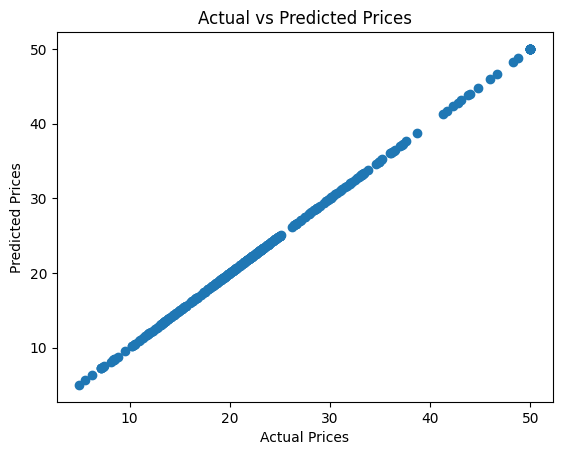

In [35]:
plt.scatter(y_train , training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# Prediction for test data

In [32]:
# finding the accuracy for testing data
testing_data_prediction = xgbr_model.predict(X_test)

In [33]:
# printing the accuracy
print(testing_data_prediction)

[24.244722  30.410286  15.067149  22.819569  16.121946  21.934534
 18.791597  15.234425  22.107586  20.931849  21.52994   18.2308
  9.895653  21.36603   19.616087  25.908554  18.380495   9.76402
 46.493134  16.397362  24.799652  25.111315  13.711699  21.3166
 15.9963665 16.189772  22.878387  14.354461  19.732048  20.356567
 20.099627  23.44589   21.49371   19.413055  13.866445  16.82372
 34.300426  17.803537  22.972012  24.30865   16.875036  30.893532
 47.652916  18.881477  22.053251  13.26211   15.778249  23.428022
 19.451662  24.059237  23.10419   35.75321   17.49301   26.67157
 47.7234    21.937538  16.372108  33.71733   22.16174   20.343548
 25.673878  30.389763  29.00689   17.614103  25.54194   17.114262
 12.119571  23.043581  30.29759   14.626157  19.43269   26.187054
 10.089485  22.257206  22.352835   7.2429514 19.894682  47.346615
 10.2119875 11.490451  22.699501  11.629095  20.619993   9.048394
 19.48496   26.383741  14.836717  23.356035  24.918026  16.938152
 22.784546   7.03

In [34]:
# R squared error
score_1 = metrics.r2_score(y_test , testing_data_prediction)

# Mean absoulte error
score_2 = metrics.mean_absolute_error(y_test , testing_data_prediction)

print("R squared error : " , score_1)

print("Mean Absoulte error : " , score_2)

R squared error :  0.8753514389204832
Mean Absoulte error :  2.059988515628012


# Visualizing the Actual Price and Predicted Price

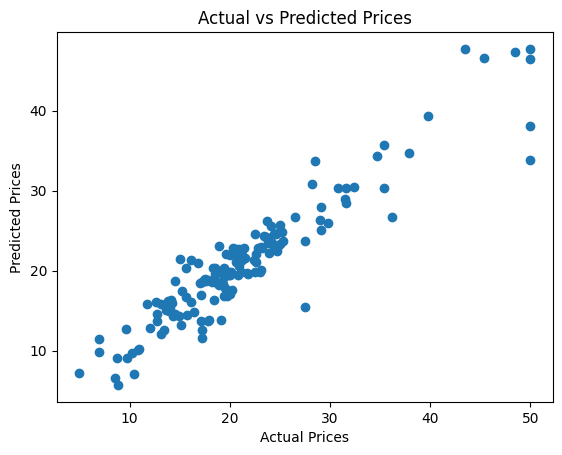

In [36]:
plt.scatter(y_test , testing_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()